<a href="https://colab.research.google.com/github/aadzy/ML-lab-2547201/blob/Lab-3/GPA_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score



In [69]:
# Load the dataset
df = pd.read_csv("/content/drive/MyDrive/ML Datasets/Lab 3/student_survey.csv")
df.head()

# Keep only the specified columns
columns_to_keep = [
    "Your CIA % of last semester",
    "Your GPA of last semester",
    "Your maximum attendance % till last semester"
]
df = df[columns_to_keep]


In [70]:
#Renaming columns for ease of readability

df = df.rename(columns={
    "Your CIA % of last semester": "CIA",
    "Your GPA of last semester": "GPA",
    "Your maximum attendance % till last semester": "Attendance"
})
df.head()

,CIA,GPA,Attendance
0,69,3.40,98
1,75,3.69,95
2,82,3.41,95
3,91,3.60,92
4,70,3.54,93


### Performing EDA and basic pre-processing of data:

In [71]:

# Display DataFrame information
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CIA         50 non-null     object 
 1   GPA         50 non-null     float64
 2   Attendance  50 non-null     object 
dtypes: float64(1), object(2)
memory usage: 1.3+ KB


In [72]:
# Clean and convert 'CIA' column to float
df['CIA'] = df['CIA'].astype(str).str.replace('%', '', regex=False)
df['CIA'] = pd.to_numeric(df['CIA'], errors='coerce')

In [73]:
# Clean and convert 'Attendance' column to float
df['Attendance'] = df['Attendance'].astype(str).str.replace('%', '', regex=False)
df['Attendance'] = pd.to_numeric(df['Attendance'], errors='coerce')

In [74]:
print('\nDataFrame Info After Cleaning:')
df.info()


DataFrame Info After Cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CIA         50 non-null     float64
 1   GPA         50 non-null     float64
 2   Attendance  50 non-null     float64
dtypes: float64(3)
memory usage: 1.3 KB


In [75]:
print('\nDescriptive Statistics After Cleaning:')
display(df.describe())


Descriptive Statistics After Cleaning:


,CIA,GPA,Attendance
count,50.000000,50.000000,50.000000
mean,71.508600,3.497000,93.824800
std,11.247756,0.690865,3.852926
min,7.000000,2.740000,85.000000
25%,69.195000,3.305000,92.000000
50%,71.445000,3.400000,95.000000
75%,76.750000,3.600000,96.000000
max,91.000000,8.000000,100.000000


We've now cleaned the values to have consistent datatype across the individual columns. Now, we can go ahead with a more deeper analysis of inconsistencies on a statistical level

### Starting with outlier removal:

The max value for GPA is 8 which is an outlier as we can see that all the quartiles are significantly lower than it.

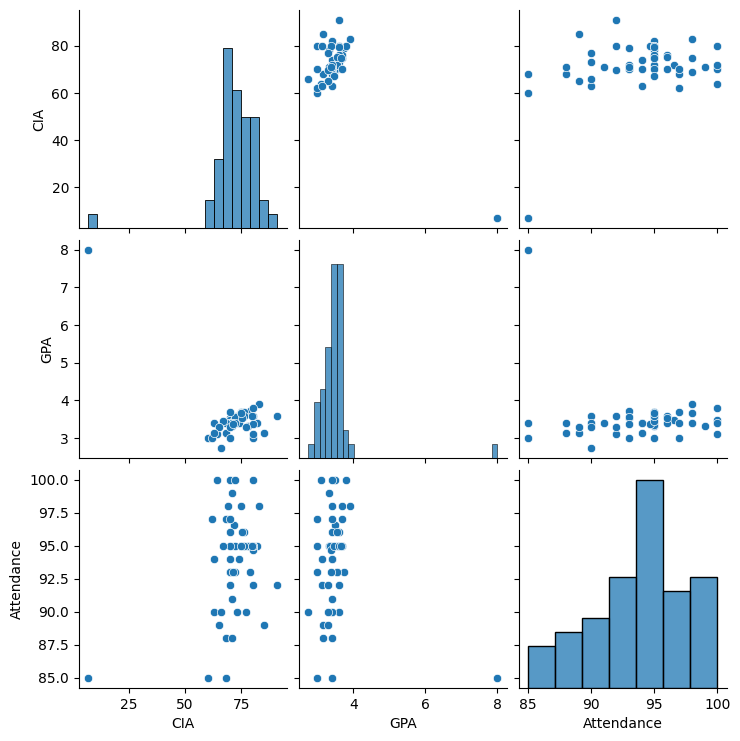

In [76]:
import seaborn as sns

#Pairplot allows us to visualize all parameters to check for any missed outliers

sns.pairplot(df)

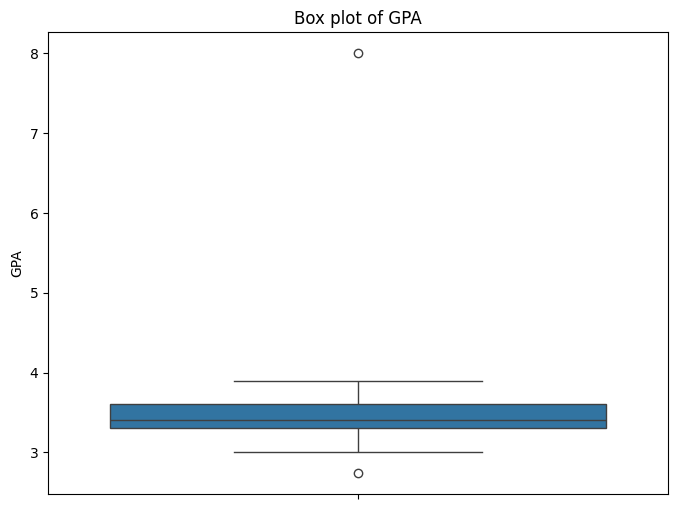

In [77]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['GPA'])
plt.title('Box plot of GPA')
plt.ylabel('GPA')
plt.show()

The outliers in GPA need to be removed


In [78]:
# Remove outliers in 'GPA' column using the IQR method
Q1_gpa = df['GPA'].quantile(0.25)
Q3_gpa = df['GPA'].quantile(0.75)
IQR_gpa = Q3_gpa - Q1_gpa

lower_bound_gpa = Q1_gpa - 1.5 * IQR_gpa
upper_bound_gpa = Q3_gpa + 1.5 * IQR_gpa

# Filter the DataFrame to remove outliers
df_filtered = df[(df['GPA'] >= lower_bound_gpa) & (df['GPA'] <= upper_bound_gpa)]

# Correctly identify outliers: values less than lower bound OR greater than upper bound
df_outliers = df[(df['GPA'] < lower_bound_gpa) | (df['GPA'] > upper_bound_gpa)]
print("Outliers that were removed:")
display(df_outliers["GPA"])

print(f"Original DataFrame shape: {df.shape}")
print(f"DataFrame shape after removing GPA outliers: {df_filtered.shape}")

# Update the original DataFrame 'df' with the filtered one
df = df_filtered.copy()

Outliers that were removed:


,GPA
13,8.00
48,2.74


Original DataFrame shape: (50, 3)
DataFrame shape after removing GPA outliers: (48, 3)


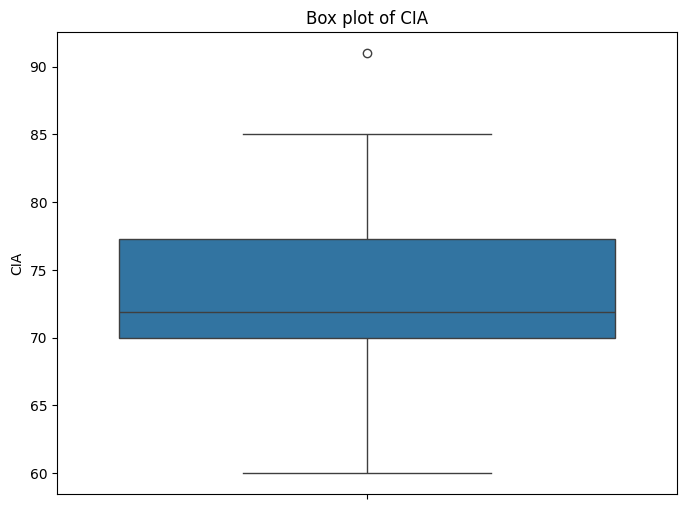


Outliers removed from CIA:


,CIA
3,91.0


Original rows for CIA: 48, Rows after removing CIA outliers: 47


In [79]:
# Build boxplot for CIA
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['CIA'])
plt.title('Box plot of CIA')
plt.ylabel('CIA')
plt.show()



# Function to remove outliers using IQR
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f"\nOutliers removed from {column}:")
    display(outliers[column])
    return df_filtered

# Remove outliers from 'CIA'
original_shape_cia = df.shape[0]
df = remove_outliers_iqr(df, 'CIA')
print(f"Original rows for CIA: {original_shape_cia}, Rows after removing CIA outliers: {df.shape[0]}")






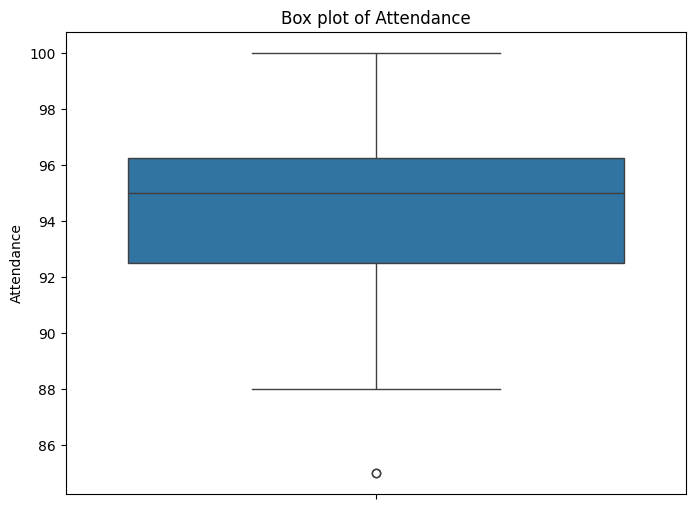


Outliers removed from Attendance:


,Attendance
7,85.0
15,85.0


In [80]:
# Build boxplot for Attendance
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Attendance'])
plt.title('Box plot of Attendance')
plt.ylabel('Attendance')
plt.show()

# Remove outliers from 'Attendance'
original_shape_attendance = df.shape[0]
df = remove_outliers_iqr(df, 'Attendance')

In [81]:

print(f"Original rows for Attendance: {original_shape_attendance}, Rows after removing Attendance outliers: {df.shape[0]}")

print("\nDataFrame Info after all outlier removals:")
df.info()

print("\nDescriptive Statistics after all outlier removals:")
display(df.describe())

Original rows for Attendance: 47, Rows after removing Attendance outliers: 45

DataFrame Info after all outlier removals:
<class 'pandas.core.frame.DataFrame'>
Index: 45 entries, 0 to 49
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CIA         45 non-null     float64
 1   GPA         45 non-null     float64
 2   Attendance  45 non-null     float64
dtypes: float64(3)
memory usage: 1.4 KB

Descriptive Statistics after all outlier removals:


,CIA,GPA,Attendance
count,45.000000,45.000000,45.000000
mean,72.965111,3.424667,94.538667
std,5.615012,0.215054,3.208243
min,62.000000,3.000000,88.000000
25%,70.000000,3.320000,93.000000
50%,72.000000,3.400000,95.000000
75%,77.000000,3.600000,96.540000
max,85.000000,3.900000,100.000000


Now, after removing all inconsistencies in the dataset. With the now cleaned data we can go ahead with the linear regression model testing.


# Experiment 1:

Building a Linear regression model on dataset using *CIA*(feature) as **independent variable** and *GPA*(target) as **dependent variable**

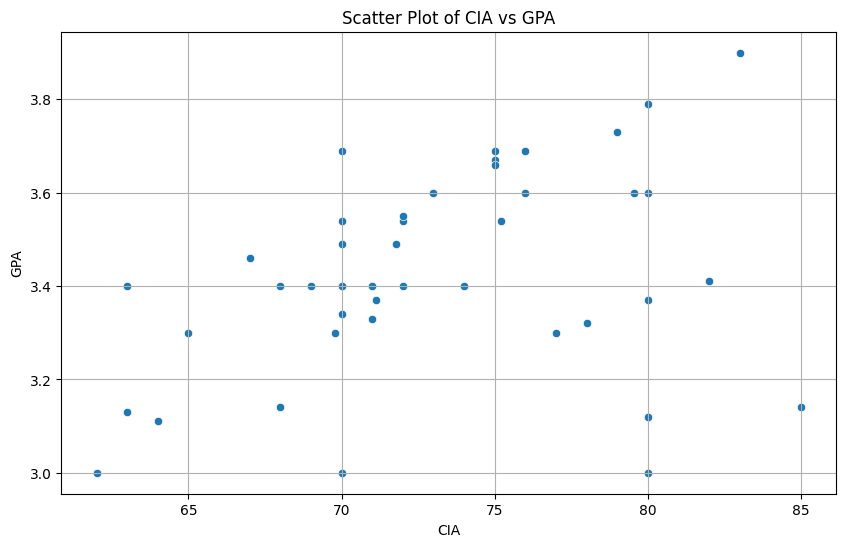

In [82]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CIA', y='GPA', data=df)
plt.title('Scatter Plot of CIA vs GPA')
plt.xlabel('CIA')
plt.ylabel('GPA')
plt.grid(True)
plt.show()

This plot shows a visual representation of how the correlation between CIA and GPA varies accross different values

Using sklearn package for pre-built Linear Regression model:

In [83]:
X = df[['CIA']]
y = df[['GPA']]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2
)


from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)


y_pred = lr.predict(X_test)



print(f"\nSklearn Intercept: {lr.intercept_[0]}")
print(f"Sklearn Slope: {lr.coef_[0][0]}")



Sklearn Intercept: 3.110171442203576
Sklearn Slope: 0.004668342305257654


In [84]:
# Manually compute OLS coefficients (slope and intercept)

# Calculate means of X_train and y_train
X_train_mean = X_train['CIA'].mean()
y_train_mean = y_train['GPA'].mean()

# Calculate the slope (coefficient)
numerator = sum((X_train['CIA'] - X_train_mean) * (y_train['GPA'] - y_train_mean))
denominator = sum((X_train['CIA'] - X_train_mean)**2)

manual_slope = numerator / denominator

# Calculate the intercept
manual_intercept = y_train_mean - manual_slope * X_train_mean

print(f"Manual Intercept: {manual_intercept}")
print(f"Manual Slope: {manual_slope}")


# Manually predict using the calculated coefficients for X_test
manual_y_pred = manual_intercept + manual_slope * X_test['CIA']


Manual Intercept: 3.110171442203576
Manual Slope: 0.004668342305257654


In [85]:
predictions_df = pd.DataFrame({
    'Actual GPA (Test)': y_test['GPA'].values,
    'Manual Predictions': manual_y_pred.values,
    'Sklearn Predictions': y_pred.flatten()
})
display(predictions_df)

,Actual GPA (Test),Manual Predictions,Sklearn Predictions
0,3.66,3.460297,3.460297
1,3.40,3.404277,3.404277
2,3.00,3.399609,3.399609
3,3.11,3.408945,3.408945
4,3.13,3.404277,3.404277
5,3.40,3.436955,3.436955
6,3.14,3.427619,3.427619
7,3.40,3.441624,3.441624
8,3.40,3.432287,3.432287


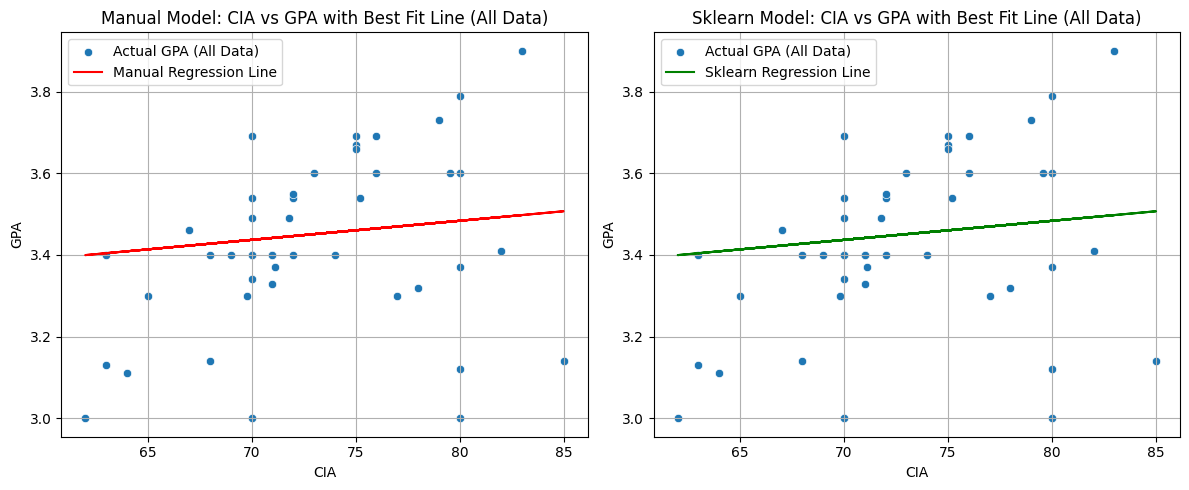

In [94]:
# Re-initialize X, y, and perform train-test split for CIA vs GPA
X = df[['CIA']]
y = df[['GPA']]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2
)

# Re-train sklearn model for CIA vs GPA
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_test = lr.predict(X_test) # Predictions for test set

# Re-calculate manual predictions for CIA vs GPA
X_train_mean = X_train['CIA'].mean()
y_train_mean = y_train['GPA'].mean()
numerator = sum((X_train['CIA'] - X_train_mean) * (y_train['GPA'] - y_train_mean))
denominator = sum((X_train['CIA'] - X_train_mean)**2)
manual_slope = numerator / denominator
manual_intercept = y_train_mean - manual_slope * X_train_mean
manual_y_pred_test = manual_intercept + manual_slope * X_test['CIA'] # Predictions for test set

# Generate predictions for the full dataset using the trained models
manual_y_pred_full = manual_intercept + manual_slope * df['CIA']
sklearn_y_pred_full = lr.predict(df[['CIA']])

plt.figure(figsize=(12, 5))

# Plot for Manual Model on full dataset
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.scatterplot(x=df['CIA'], y=df['GPA'], label='Actual GPA (All Data)')
plt.plot(df['CIA'], manual_y_pred_full, color='red', label='Manual Regression Line')
plt.title('Manual Model: CIA vs GPA with Best Fit Line (All Data)')
plt.xlabel('CIA')
plt.ylabel('GPA')
plt.grid(True)
plt.legend()

# Plot for Sklearn Model on full dataset
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.scatterplot(x=df['CIA'], y=df['GPA'], label='Actual GPA (All Data)')
plt.plot(df['CIA'], sklearn_y_pred_full, color='green', label='Sklearn Regression Line')
plt.title('Sklearn Model: CIA vs GPA with Best Fit Line (All Data)')
plt.xlabel('CIA')
plt.ylabel('GPA')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [86]:
print("\n--- Model Evaluation Metrics (Manual Predictions) ---")
print(f"Manual Mean Absolute Error (MAE): {mean_absolute_error(y_test, manual_y_pred):.4f}")
print(f"Manual Mean Squared Error (MSE): {mean_squared_error(y_test, manual_y_pred):.4f}")
print(f"Manual Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, manual_y_pred)):.4f}")
print(f"Manual R-squared (R2): {r2_score(y_test, manual_y_pred):.4f}")

print("\n--- Model Evaluation Metrics (Sklearn Predictions) ---")
print(f"Sklearn Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.4f}")
print(f"Sklearn Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.4f}")
print(f"Sklearn Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"Sklearn R-squared (R2): {r2_score(y_test, y_pred):.4f}")


--- Model Evaluation Metrics (Manual Predictions) ---
Manual Mean Absolute Error (MAE): 0.1750
Manual Mean Squared Error (MSE): 0.0501
Manual Root Mean Squared Error (RMSE): 0.2239
Manual R-squared (R2): -0.2894

--- Model Evaluation Metrics (Sklearn Predictions) ---
Sklearn Mean Absolute Error (MAE): 0.1750
Sklearn Mean Squared Error (MSE): 0.0501
Sklearn Root Mean Squared Error (RMSE): 0.2239
Sklearn R-squared (R2): -0.2894


Here, we can clearly see that there's no difference between the manual and Sci-kit learn model. The best fit line is exactly the same. And to finally conclude, the metrics also show the same values for both models.

Creating a **pickle file** to store the model and predict in future:




In [100]:
import pickle

# NOTE: The 'lr' variable currently holds the model for 'Attendance vs GPA'
# To get the CIA vs GPA model parameters, we need to re-run the CIA vs GPA model training.
# For demonstration, we will assume 'lr' was last trained on 'CIA vs GPA' here.
# In a real scenario, you'd re-train or ensure the correct model object is available.

# Re-train the CIA vs GPA model to ensure we get its coefficients
X_cia = df[['CIA']]
y_gpa = df[['GPA']]

X_train_cia, X_test_cia, y_train_gpa, y_test_gpa = train_test_split(
    X_cia,
    y_gpa,
    test_size=0.2,
    random_state=2
)

lr_cia = LinearRegression()
lr_cia.fit(X_train_cia, y_train_gpa)

# Get the slope and intercept from the 'CIA vs GPA' trained model
slope_cia_to_save = lr_cia.coef_[0][0]
intercept_cia_to_save = lr_cia.intercept_[0]

# Save only the slope and intercept to a pickle file
filename_cia = 'cia_gpa_params.pkl'
with open(filename_cia, 'wb') as file:
    pickle.dump({'slope': slope_cia_to_save, 'intercept': intercept_cia_to_save}, file)

print(f"CIA vs GPA model parameters (slope and intercept) saved to {filename_cia}")

# --- Now, demonstrate loading and predicting with these parameters ---

# Load the saved slope and intercept
with open(filename_cia, 'rb') as file:
    loaded_params_cia = pickle.load(file)

slope_cia = loaded_params_cia['slope']
intercept_cia = loaded_params_cia['intercept']

print(f"\nLoaded Slope (CIA vs GPA): {slope_cia}")
print(f"Loaded Intercept (CIA vs GPA): {intercept_cia}")

def predict_gpa_from_cia(cia_percentage):
    """
    Predicts GPA based on CIA percentage using the loaded slope and intercept.

    Args:
        cia_percentage (float): The CIA percentage.

    Returns:
        float: The predicted GPA.
    """
    # Use the linear regression formula: y = mx + b
    predicted_gpa = slope_cia * cia_percentage + intercept_cia
    return predicted_gpa

# Example usage:
cia_input = 75.0
predicted_gpa_from_cia = predict_gpa_from_cia(cia_input)
print(f"For a CIA of {cia_input}%, the predicted GPA is: {predicted_gpa_from_cia:.2f}")

CIA vs GPA model parameters (slope and intercept) saved to cia_gpa_params.pkl

Loaded Slope (CIA vs GPA): 0.004668342305257654
Loaded Intercept (CIA vs GPA): 3.110171442203576
For a CIA of 75.0%, the predicted GPA is: 3.46


# Experiment 2:

Building a Linear regression model on dataset using *Attendance*(feature) as **independent variable** and *GPA*(target) as **dependent variable**

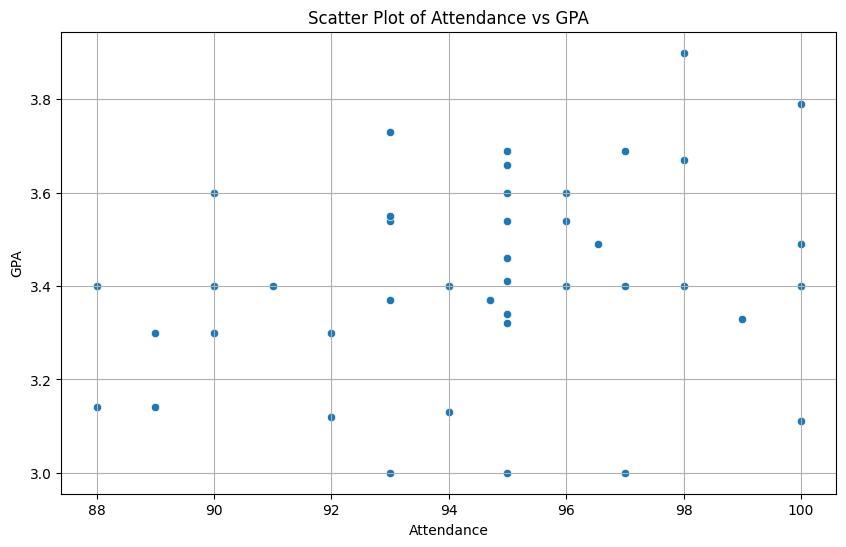

In [87]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Attendance', y='GPA', data=df)
plt.title('Scatter Plot of Attendance vs GPA')
plt.xlabel('Attendance')
plt.ylabel('GPA')
plt.grid(True)
plt.show()

This plot shows a visual representation of how the correlation between Attendance and GPA varies accross different values

Using sklearn package for pre-built Linear Regression model:

In [88]:
X = df[['Attendance']]
y = df[['GPA']]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2
)


from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)


y_pred = lr.predict(X_test)



print(f"\nSklearn Intercept: {lr.intercept_[0]}")
print(f"Sklearn Slope: {lr.coef_[0][0]}")



Sklearn Intercept: 0.9606717111928038
Sklearn Slope: 0.026380829761642584


In [89]:
# Manually compute OLS coefficients (slope and intercept)

# Calculate means of X_train and y_train
X_train_mean = X_train['Attendance'].mean()
y_train_mean = y_train['GPA'].mean()

# Calculate the slope (coefficient)
numerator = sum((X_train['Attendance'] - X_train_mean) * (y_train['GPA'] - y_train_mean))
denominator = sum((X_train['Attendance'] - X_train_mean)**2)

manual_slope = numerator / denominator

# Calculate the intercept
manual_intercept = y_train_mean - manual_slope * X_train_mean

print(f"Manual Intercept: {manual_intercept}")
print(f"Manual Slope: {manual_slope}")


# Manually predict using the calculated coefficients for X_test
manual_y_pred = manual_intercept + manual_slope * X_test['Attendance']


Manual Intercept: 0.9606717111928034
Manual Slope: 0.026380829761642587


In [90]:
predictions_df = pd.DataFrame({
    'Actual GPA (Test)': y_test['GPA'].values,
    'Manual Predictions': manual_y_pred.values,
    'Sklearn Predictions': y_pred.flatten()
})
display(predictions_df)

,Actual GPA (Test),Manual Predictions,Sklearn Predictions
0,3.66,3.466851,3.466851
1,3.40,3.334946,3.334946
2,3.00,3.519612,3.519612
3,3.11,3.598755,3.598755
4,3.13,3.440470,3.440470
5,3.40,3.440470,3.440470
6,3.14,3.282185,3.282185
7,3.40,3.361327,3.361327
8,3.40,3.545993,3.545993


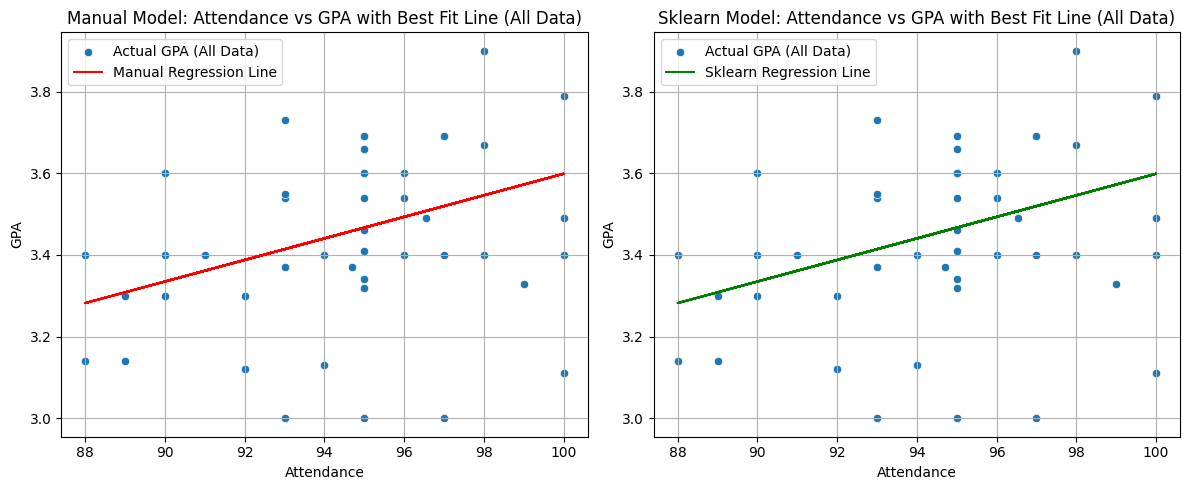

In [95]:
# Re-initialize X, y, and perform train-test split for Attendance vs GPA
X = df[['Attendance']]
y = df[['GPA']]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2
)

# Re-train sklearn model for Attendance vs GPA
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_test = lr.predict(X_test) # Predictions for test set

# Re-calculate manual predictions for Attendance vs GPA
X_train_mean = X_train['Attendance'].mean()
y_train_mean = y_train['GPA'].mean()
numerator = sum((X_train['Attendance'] - X_train_mean) * (y_train['GPA'] - y_train_mean))
denominator = sum((X_train['Attendance'] - X_train_mean)**2)
manual_slope = numerator / denominator
manual_intercept = y_train_mean - manual_slope * X_train_mean
manual_y_pred_test = manual_intercept + manual_slope * X_test['Attendance'] # Predictions for test set

# Generate predictions for the full dataset using the trained models
manual_y_pred_full = manual_intercept + manual_slope * df['Attendance']
sklearn_y_pred_full = lr.predict(df[['Attendance']])

plt.figure(figsize=(12, 5))

# Plot for Manual Model on full dataset
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.scatterplot(x=df['Attendance'], y=df['GPA'], label='Actual GPA (All Data)')
plt.plot(df['Attendance'], manual_y_pred_full, color='red', label='Manual Regression Line')
plt.title('Manual Model: Attendance vs GPA with Best Fit Line (All Data)')
plt.xlabel('Attendance')
plt.ylabel('GPA')
plt.grid(True)
plt.legend()

# Plot for Sklearn Model on full dataset
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.scatterplot(x=df['Attendance'], y=df['GPA'], label='Actual GPA (All Data)')
plt.plot(df['Attendance'], sklearn_y_pred_full, color='green', label='Sklearn Regression Line')
plt.title('Sklearn Model: Attendance vs GPA with Best Fit Line (All Data)')
plt.xlabel('Attendance')
plt.ylabel('GPA')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [91]:
print("\n--- Model Evaluation Metrics (Manual Predictions) ---")
print(f"Manual Mean Absolute Error (MAE): {mean_absolute_error(y_test, manual_y_pred):.4f}")
print(f"Manual Mean Squared Error (MSE): {mean_squared_error(y_test, manual_y_pred):.4f}")
print(f"Manual Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, manual_y_pred)):.4f}")
print(f"Manual R-squared (R2): {r2_score(y_test, manual_y_pred):.4f}")

print("\n--- Model Evaluation Metrics (Sklearn Predictions) ---")
print(f"Sklearn Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.4f}")
print(f"Sklearn Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.4f}")
print(f"Sklearn Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"Sklearn R-squared (R2): {r2_score(y_test, y_pred):.4f}")


--- Model Evaluation Metrics (Manual Predictions) ---
Manual Mean Absolute Error (MAE): 0.2160
Manual Mean Squared Error (MSE): 0.0768
Manual Root Mean Squared Error (RMSE): 0.2772
Manual R-squared (R2): -0.9768

--- Model Evaluation Metrics (Sklearn Predictions) ---
Sklearn Mean Absolute Error (MAE): 0.2160
Sklearn Mean Squared Error (MSE): 0.0768
Sklearn Root Mean Squared Error (RMSE): 0.2772
Sklearn R-squared (R2): -0.9768


The other selection of feature also depicts a similar outcome:

We can see that there's no difference between the manual and Sci-kit learn model again.

The best fit line and the metrics are exactly the same.

### Creating a pickle file for this model:

In [98]:
import pickle

# Get the slope and intercept from the trained model (lr)
slope_to_save = lr.coef_[0][0]
intercept_to_save = lr.intercept_[0]

# Save only the slope and intercept to a pickle file
filename = 'attendance_gpa_params.pkl'
with open(filename, 'wb') as file:
    pickle.dump({'slope': slope_to_save, 'intercept': intercept_to_save}, file)

print(f"Slope and intercept saved to {filename}")

Slope and intercept saved to attendance_gpa_params.pkl


### Predict GPA based on Attendance using the saved model

In [99]:
import pickle

# Load the saved slope and intercept
filename = 'attendance_gpa_params.pkl'
with open(filename, 'rb') as file:
    loaded_params = pickle.load(file)

slope = loaded_params['slope']
intercept = loaded_params['intercept']

print(f"Loaded Slope: {slope}")
print(f"Loaded Intercept: {intercept}")

def predict_gpa(attendance_percentage):

    # Use the linear regression formula: y = mx + b
    predicted_gpa = slope * attendance_percentage + intercept
    return predicted_gpa

# Example usage:
attendance_input = 90.0
predicted_gpa = predict_gpa(attendance_input)
print(f"For an attendance of {attendance_input}%, the predicted GPA is: {predicted_gpa:.2f}")

Loaded Slope: 0.026380829761642584
Loaded Intercept: 0.9606717111928038
For an attendance of 90.0%, the predicted GPA is: 3.33


# Final Conclusion & Inference:


Before model development, several preprocessing and exploratory analysis steps were performed to ensure data quality and reliability.

The dataset was cleaned by converting percentage-based values (e.g., "97%") into numerical float values, handling datatype inconsistencies, and removing outliers that could adversely affect model performance.

Exploratory Data Analysis (EDA) was then conducted to understand data distributions, identify trends, and examine the relationships between Attendance, CIA marks, and GPA.

**Four linear regression models were evaluated:**

Manual Linear Regression (CIA → GPA)

Scikit-Learn Linear Regression (CIA → GPA)

Manual Linear Regression (Attendance → GPA)

Scikit-Learn Linear Regression (Attendance → GPA)


**Comparison of Manual vs Scikit-Learn Models**

The manual implementation and the Scikit-Learn implementation produced identical regression lines and identical evaluation metrics for both feature sets. This confirms that the manual calculations were implemented correctly and that both approaches represent the same linear regression model.


Among the two features, CIA marks performed better than Attendance in predicting GPA:

Lower MAE (0.1750 vs 0.2160)

Lower RMSE (0.2239 vs 0.2772)

Higher R² (-0.2894 vs -0.9768)

## Overall Inference
The manual and Scikit-Learn models are **equivalent**, validating the correctness of the manual implementation.

CIA marks are a **stronger predictor** of GPA than Attendance, as evidenced by **lower prediction errors** and a higher R² value.

However, the weak fit and negative R² values suggest that GPA is influenced by additional factors beyond CIA marks and Attendance.

Therefore, a more accurate predictive model would likely require multiple features (multivariate regression) rather than relying on a single independent variable.